#  Fake News Detection using Machine Learning

##  Introduction
Fake news has become a serious issue in today’s digital world. With the rise of social media and online news platforms, it is very easy for false information to spread quickly.

In this project, we build a machine learning model that can classify news articles as **real or fake** based on their text content.

##  Objective
- To detect fake and real news articles
- To apply Natural Language Processing (NLP)
- To build a classification model

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
from google.colab import files
uploaded  = files.upload()

Saving fake_or_real_news.csv to fake_or_real_news.csv


In [ ]:
df = pd.DataFrame(pd.read_csv("fake_or_real_news.csv"))

##  Dataset
The dataset contains news articles labeled as fake or real.
It includes:
- Title
- Text
- Label

In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 5.9 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:12<00:00,  3.18s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

##  Data Preprocessing
- Removing null values
- Cleaning text data
- Converting text into numerical form using TF-IDF

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
title,0
text,0
label,0


In [ ]:
df.describe()

,Unnamed: 0
count,6335.000000
mean,5280.415627
std,3038.503953
min,2.000000
25%,2674.500000
50%,5271.000000
75%,7901.000000
max,10557.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
df.shape

(6335, 4)

In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Original column 'text' ko clean_text se replace karna
df["text"] = df["text"].apply(clean_text)

# Check karo top 5 rows
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,daniel greenfield shillman journalism fellow f...,FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,google pinterest digg linkedin reddit stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,us secretary state john f kerry said monday st...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,kaydee king kaydeeking november lesson tonight...,FAKE
4,875,The Battle of New York: Why This Primary Matters,primary day new york frontrunners hillary clin...,REAL


In [ ]:
# Original column 'text' ko clean_text se replace karna
df["title"] = df["title"].apply(clean_text)

# Check karo top 5 rows
df.head()

,Unnamed: 0,title,text,label
0,8476,smell hillarys fear,daniel greenfield shillman journalism fellow f...,FAKE
1,10294,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...,FAKE
2,3608,kerry go paris gesture sympathy,us secretary state john f kerry said monday st...,REAL
3,10142,bernie supporters twitter erupt anger dnc trie...,kaydee king kaydeeking november lesson tonight...,FAKE
4,875,battle new york primary matters,primary day new york frontrunners hillary clin...,REAL


In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,8476,smell hillarys fear,daniel greenfield shillman journalism fellow f...,FAKE
1,10294,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...,FAKE
2,3608,kerry go paris gesture sympathy,us secretary state john f kerry said monday st...,REAL
3,10142,bernie supporters twitter erupt anger dnc trie...,kaydee king kaydeeking november lesson tonight...,FAKE
4,875,battle new york primary matters,primary day new york frontrunners hillary clin...,REAL


In [ ]:
# "Unnamed: 0" column remove karna
df = df.drop(columns=["Unnamed: 0"])

# Confirm karo
df.head()

,title,text,label
0,smell hillarys fear,daniel greenfield shillman journalism fellow f...,FAKE
1,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...,FAKE
2,kerry go paris gesture sympathy,us secretary state john f kerry said monday st...,REAL
3,bernie supporters twitter erupt anger dnc trie...,kaydee king kaydeeking november lesson tonight...,FAKE
4,battle new york primary matters,primary day new york frontrunners hillary clin...,REAL


In [ ]:
# Convert label to 0 and 1
# 0 = REAL, 1 = FAKE
df['label'] = df['label'].map({'REAL': 0, 'FAKE': 1})

# Check
df['label'].value_counts()

,count
label,
0,3171
1,3164


In [ ]:
df.head()

,title,text,label
0,smell hillarys fear,daniel greenfield shillman journalism fellow f...,1
1,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...,1
2,kerry go paris gesture sympathy,us secretary state john f kerry said monday st...,0
3,bernie supporters twitter erupt anger dnc trie...,kaydee king kaydeeking november lesson tonight...,1
4,battle new york primary matters,primary day new york frontrunners hillary clin...,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   6335 non-null   object
 1   text    6335 non-null   object
 2   label   6335 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 148.6+ KB


In [ ]:
df["combined"] = df["title"] + " " + df["text"]
df.head()

,title,text,label,combined
0,smell hillarys fear,daniel greenfield shillman journalism fellow f...,1,smell hillarys fear daniel greenfield shillman...
1,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...,1,watch exact moment paul ryan committed politic...
2,kerry go paris gesture sympathy,us secretary state john f kerry said monday st...,0,kerry go paris gesture sympathy us secretary s...
3,bernie supporters twitter erupt anger dnc trie...,kaydee king kaydeeking november lesson tonight...,1,bernie supporters twitter erupt anger dnc trie...
4,battle new york primary matters,primary day new york frontrunners hillary clin...,0,battle new york primary matters primary day ne...


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

In [ ]:
X = vectorizer.fit_transform(df["combined"])

In [ ]:
y = df["label"]

In [ ]:
print(X.shape)

(6335, 5000)


In [ ]:
print (y.shape)

(6335,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Model Building
We use machine learning algorithms such as Logistic Regression to train the model.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

##  Model Evaluation
We evaluate the model using accuracy score and confusion matrix.

In [ ]:
 from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9179163378058406


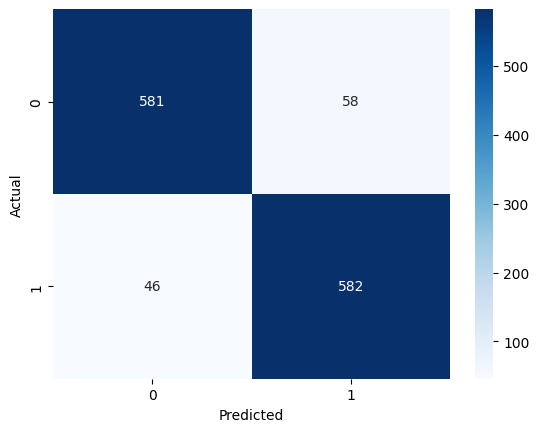

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       639
           1       0.91      0.93      0.92       628

    accuracy                           0.92      1267
   macro avg       0.92      0.92      0.92      1267
weighted avg       0.92      0.92      0.92      1267



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix calculate karo
cm = confusion_matrix(y_test, y_pred)

# Heatmap se visualize karo
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Detailed report
print(classification_report(y_test, y_pred))

##  Conclusion
This project shows how machine learning can help detect fake news and reduce misinformation.

In [ ]:
new_news = ["Breaking: Major election fraud reported today!"]

# Clean text same function se
new_news_clean = [clean_text(text) for text in new_news]

# TF-IDF transform
new_vector = vectorizer.transform(new_news_clean)

# Prediction
prediction = model.predict(new_vector)
print("Prediction:", prediction)
# 1 = Fake, 0 = Real

Prediction: [1]


# **Thank you**: